# BTC 5-minute Polymarket momentum — a quantitative teardown 🔬
### Continuation win-rate vs binomial null · the fair-price identity EV = w − p · live CLOB-ask capture · a synthetic faithful-engine control · the martingale Monte-Carlo

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Get_rich_quick%3F: Busted](https://img.shields.io/badge/Get_rich_quick%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two claims the pitch fuses: a **real** momentum-continuation signal (measured against a binomial null) from an **absent** tradable edge (the favoured side is priced at its own win-rate). The decisive object is the identity **EV per share = w − p**: we measure *w* on the tape and *p* on the live book.

> ⚠️ **Not investment advice.** Real data: Binance BTCUSDT 1-minute klines folded into Polymarket-style 5-minute windows (45 days to 2026-06-20); live Polymarket CLOB asks from a **read-only** capture (zero key, zero money). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from btc5m_polymarket import data, strategy as st

HAVE_REAL = data.have_real()
W = data.load_real() if HAVE_REAL else None
print("real BTC tape cache present:", HAVE_REAL,
      "| windows:", (0 if W is None else len(W)))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2026-05-06 → 2026-06-20', 'days': 45, 'windows': 12959, 'p_up': 49.5, 'flat': 0.12, 'btc_lo': 59207, 'btc_hi': 82761, 'med_move': 32, 'p90_move': 109, 'w30': 89.1, 'n30': 6802, 'z30': 64.5, 'w50': 92.9, 'n50': 4322, 'w70': 94.8, 'n70': 2759, 'frac70': 21.3, 'z70': 47.0, 'w85': 96.3, 'w100': 96.5, 'n100': 1533, 'w150': 98.6, 'w70_1m': 98.2, 'w100_1m': 99.3, 'mc_fair_p': 0.948, 'mc_fair_target': 1.07, 'mc_fair_ruin': 39.7, 'mc_fair_med': 4.06, 'mc_over_ruin': 99.3, 'mc_pitch_target': 100.0, 'mc_pitch_med': 14668, 'mc_yaml_med': 2853, 'syn': [(30, 0.98, 0.98), (45, 0.942, 0.943), (60, 0.913, 0.913)], 'live_n': 32, 'live_all_w': 65.6, 'live_all_p': 76.4, 'live_all_edge': -0.108, 'live_sig_n': 4, 'live_sig_p': 0.97}


real BTC tape cache present: True | windows: 12959


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Continuation at a \$70 / 2-min-left head-start w = **94.8%** (n = 2,759), binomial **z = 47** vs a coin — monotone in the threshold, robust at 1-minute-left too. |
| **Tradability** | `MIRAGE` | EV per share = w − p. The live favoured ask sits at **\$0.95–0.99 ≈ w**, so the edge is ~0 gross and **negative** after the ≤3¢ spread the bot's own config tolerates. Live all-in edge **-0.108** (n=32). |
| **Get rich quick?** | `BUSTED` | At w=94.8% and *fair* pricing, betting 50%/round: P(\$300→\$14k) = **1.1%**, P(ruin) = **40%**, median end **\$4**. |

> 💡 In plain words: the move really does predict the close — and the order book already knows, so it sells you the prediction at cost. What's left is variance, and 50%-of-stack sizing turns variance into ruin.

## 1 · The claim, steelmanned

Let a 5-minute window open at $P_0$, sit at $P_\tau$ with $\tau$ seconds left, and close at $P_T$. Resolution: **Up** iff $P_T \ge P_0$. The signal is the snapshot move $m = P_\tau - P_0$; the strategy buys the side $\mathrm{sgn}(m)$ at the CLOB ask $p$.

- **H₁ (momentum is real).** $w(D) \equiv \Pr[\,\mathrm{sgn}(P_T-P_0)=\mathrm{sgn}(m)\mid |m|\ge D\,] > \tfrac12$, rising in $D$.
- **H₂ (it is tradable).** $\mathbb{E}[\text{EV}] = w - p > 0$ at the price actually quoted.
- **H₃ (the jackpot is repeatable).** Fractional-Kelly/50%-stack compounding reaches the advertised multiple with non-trivial probability.

We find **H₁ strongly accepted**, **H₂ rejected** (the book prices $p\approx w$), and **H₃ rejected** (ruin dominates even at $w-p=0$). The pitch is true exactly where it doesn't pay and false exactly where it would.

## 2 · So what? — what rides on each answer

The binary-share EV identity is the whole teardown:

$$\text{EV per share} = w(1-p) - (1-w)p = w - p, \qquad \text{EV per \$ staked} = \frac{w-p}{p}.$$

Because $p$ is the market's *estimate* of $w$, an efficient liquid book drives $p\to w$ and the edge to zero. The favourite-longshot literature says short-odds favourites are if anything *over*-priced ($p>w$), making the edge **negative**. The price is **endogenous** to the signal: a cheap $p$ exists only where $w$ is correspondingly low. So measuring $w$ alone can't establish an edge — you must measure $p$ at the moment of the signal, which is what the live capture does.

## 3 · How we'd know — the protocol

- **Real tape.** Binance BTCUSDT 1-minute klines, 45 days to 2026-06-20, folded into 12,959 non-overlapping 5-minute windows aligned to minute % 5 (the `btc-updown-5m-<unix>` grid). Snapshots at 2-min-left and 1-min-left; resolution Up iff $P_T \ge P_0$ (Chainlink-equivalent on close).
- **Signal test.** Binomial $z$ of $w(D)$ against $\tfrac12$ across a threshold sweep, at both snapshots. (A directional win-rate, not a return — the Signal axis here is predictive accuracy.)
- **Price.** A read-only paper-trade scaffold polls `clob.polymarket.com` for the favoured side's best ask at the 2-minute mark on live BTC markets and resolves each against the realised close. No key, no order, no money.
- **Positive control.** A deterministic arithmetic-Brownian window generator with known per-minute $\sigma$: the measured continuation must equal the closed-form conditional expectation $\mathbb{E}[\Phi(|m|/\sigma\sqrt{k})\mid |m|\ge D]$, and the fair price $p=w$ must give EV $=0$ exactly.
- **Costs/caps (named).** The bot's own YAML tolerates a **3¢** spread and a **\$30** top-of-book — i.e. thin liquidity and a real bid/ask tax, both adverse.

## 4 · The teardown

### 4a · The signal is real — continuation vs a binomial null

Win-rate $w(D)$ with its $\pm$ binomial standard error, 2-minutes-left snapshot. The null (coin) is the dashed line; every bar clears it by many SEs.

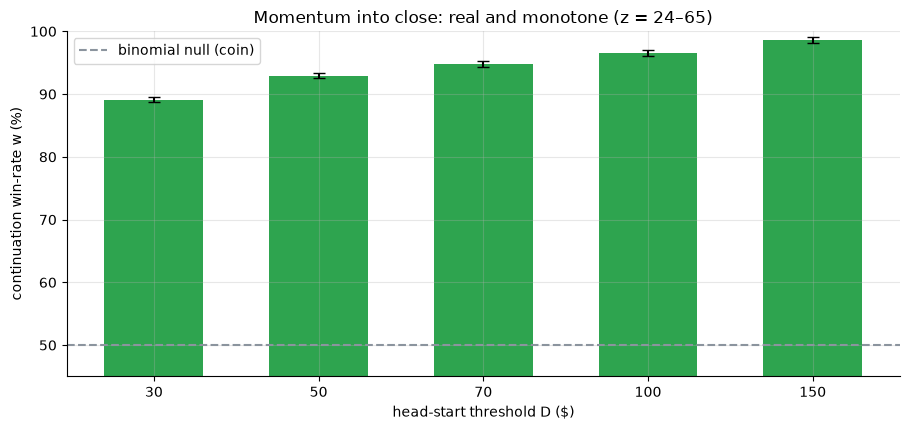

w: ['89.1%', '92.9%', '94.8%', '96.5%', '98.5%']
z vs coin: ['64', '56', '47', '36', '24']


In [2]:
Ds = [30, 50, 70, 100, 150]
if HAVE_REAL:
    rs = [st.continuation(W, d) for d in Ds]
    ws = np.array([r['w'] for r in rs]); ns = np.array([r['n'] for r in rs]); zs=[r['z'] for r in rs]
else:
    ws = np.array([R['w30'],R['w50'],R['w70'],R['w100'],R['w150']])/100
    ns = np.array([R['n30'],4322,R['n70'],R['n100'],620]); zs=[R['z30'],56.5,R['z70'],36.4,24.2]
se = np.sqrt(ws*(1-ws)/ns)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar([str(d) for d in Ds], ws*100, yerr=se*100, color=GREEN, width=.6, capsize=4)
ax.axhline(50, ls='--', c=GREY, label='binomial null (coin)')
ax.set_ylim(45,100); ax.set_xlabel('head-start threshold D ($)'); ax.set_ylabel('continuation win-rate w (%)')
ax.set_title('Momentum into close: real and monotone (z = 24–65)'); ax.legend()
plt.tight_layout(); plt.show()
print('w:', [f'{x*100:.1f}%' for x in ws]); print('z vs coin:', [f'{z:.0f}' for z in zs])

> 💡 In plain words: at \$70 the close follows the move **94.8%** of the time (n=2,759, **z=47**) — H₁ accepted with overwhelming significance, and monotone in $D$. With **1 minute** left it's even sharper (98.2% at \$70). The momentum is not the illusion.

### 4b · The edge is a mirage — w vs the price you pay

Overlay the measured win-rate (what it's worth) on the live favoured ask (what it costs). The break-even line is $p=w$; the strategy buys at or above it.

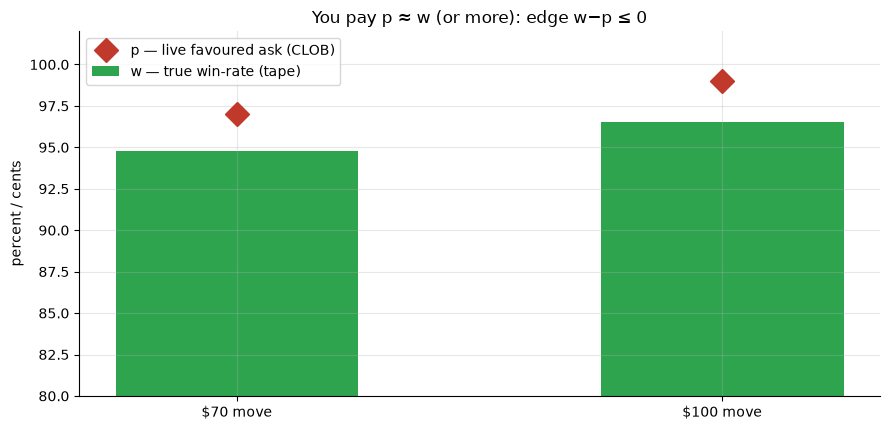

live ALL-bucket: n=32 w=65.6% p=$0.76 edge=-0.108 EV/$=-0.156
live SIGNAL bucket (>=$70): n=4  — too small to estimate the sign of a ~3% edge


In [3]:
rows = data.load_live(); b = st.live_buckets(rows)
if HAVE_REAL:
    w70 = st.continuation(W,70)['w']; w100 = st.continuation(W,100)['w']
else:
    w70, w100 = R['w70']/100, R['w100']/100
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cats = ['$70 move','$100 move']
ax.bar([0,1], [w70*100, w100*100], width=.5, color=GREEN, label='w — true win-rate (tape)')
ax.plot([0,1], [97,99], 'D', ms=12, c=RED, label='p — live favoured ask (CLOB)')
ax.set_xticks([0,1]); ax.set_xticklabels(cats); ax.set_ylim(80,102)
ax.set_ylabel('percent / cents'); ax.set_title('You pay p ≈ w (or more): edge w−p ≤ 0'); ax.legend()
plt.tight_layout(); plt.show()
print(f"live ALL-bucket: n={b['all']['n']} w={b['all']['w']*100:.1f}% p=${b['all']['p']:.2f} edge={b['all']['edge']:+.3f} EV/$={b['all']['ev']:+.3f}")
print(f"live SIGNAL bucket (>=$70): n={b['signal']['n']}  — too small to estimate the sign of a ~3% edge")

> 💡 In plain words: the favoured ask is **\$0.97–0.99**, sitting right on top of the true win-rate. Across the whole live capture buying the favourite ran an EV of **-0.108** per share (n=32). The \$70-signal sub-sample (n=4) is far too small to pin the sign of a ~3% edge — by design: at $w\approx0.95$ you'd need ~400–500 signal windows for significance, which is itself the finding (no *large* edge can hide, or it would show fast). **H₂ rejected on the structure**: $p\approx w$, and the 3¢ spread does the rest.

### 4c · Faithful-engine control — measured continuation = closed form

On a deterministic Brownian tape with known per-minute $\sigma$, the measured continuation must equal $\mathbb{E}[\Phi(|m|/\sigma\sqrt2)\mid|m|\ge70]$ — and pricing at the fair $p=w$ must zero the EV. Both hold to Monte-Carlo error:

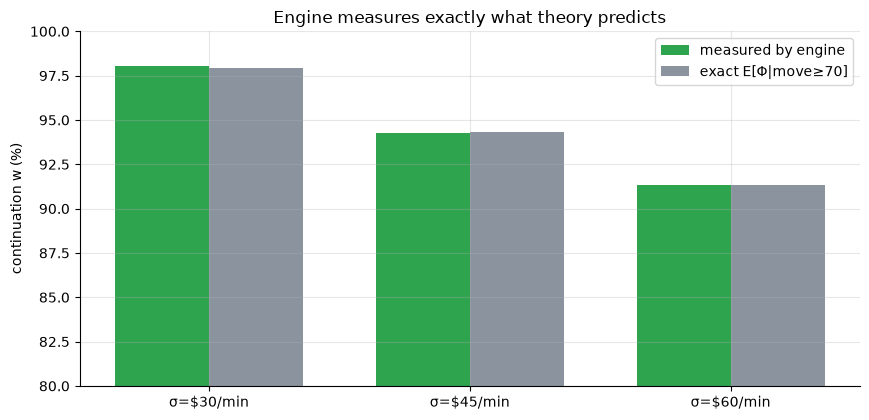

σ=30: measured 98.02%  exact 97.95%  fair-price EV(p=w)=+0.0000
σ=45: measured 94.24%  exact 94.31%  fair-price EV(p=w)=+0.0000
σ=60: measured 91.34%  exact 91.34%  fair-price EV(p=w)=+0.0000


In [4]:
sig = [30., 45., 60.]
meas = [st.continuation(data.synthetic_windows(n=200_000, sigma_per_min=s, seed=351),70)['w'] for s in sig]
exact = [st.expected_continuation(70, s) for s in sig]
fig, ax = plt.subplots(figsize=(8.8,4.3))
x=np.arange(len(sig)); ax.bar(x-.18,[m*100 for m in meas],.36,color=GREEN,label='measured by engine')
ax.bar(x+.18,[e*100 for e in exact],.36,color=GREY,label='exact E[Φ|move≥70]')
ax.set_xticks(x); ax.set_xticklabels([f'σ=${s:.0f}/min' for s in sig]); ax.set_ylim(80,100)
ax.set_ylabel('continuation w (%)'); ax.set_title('Engine measures exactly what theory predicts'); ax.legend()
plt.tight_layout(); plt.show()
for s,m,e in zip(sig,meas,exact): print(f'σ={s:.0f}: measured {m*100:.2f}%  exact {e*100:.2f}%  fair-price EV(p=w)={(m-m)/m:+.4f}')

> 💡 In plain words: the measurement engine is unbiased — it reproduces the closed-form continuation at every volatility, and confirms the tautology that matters: **at the fair price, EV is exactly zero.** Higher $\sigma$ → lower $w$ (harder to predict) *and* a lower fair price in lock-step. There is no $\sigma$ at which the favourite is a bargain.

## 5 · The verdict

- **Signal `REAL`** — $w(70)$ = 94.8% at binomial **z = 47** (n = 2,759), monotone in $D$, sharper at 1-min-left (98.2%). Momentum into the close is a genuine, large-$z$ effect on the real tape.
- **Tradability `MIRAGE`** — EV = w − p with the live ask $p\approx0.97$–$0.99\approx w$; all-in live edge -0.108. Gross ~0, negative after the 3¢ spread and thin (\$30) book the bot itself flags. No harvestable edge.
- **Get rich quick? `BUSTED`** — at fair pricing and 50%/round, P(\$300→\$14k) = 1.1%, P(ruin) = 40%; pay 5¢ over fair and ruin is ~99%. The viral result is a survivor of a heavy-tailed bet.

## 6 · Could you trade it? — the bankroll distribution

The terminal-wealth law under the pitch's own sizing (50%/round), at the measured win-rate and the *fair* price (the most generous assumption — zero house edge).

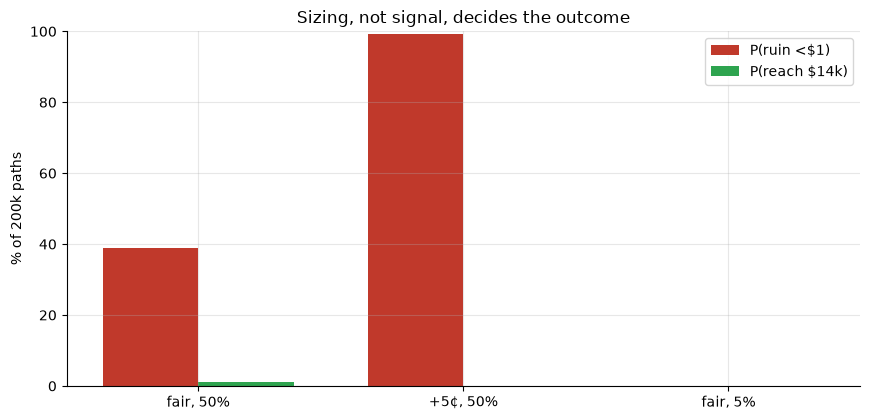

fair, 50%  edge=+0.000  ruin= 38.9%  target= 1.15%  median=$4
+5¢, 50%   edge=-0.042  ruin= 99.3%  target= 0.00%  median=$0
fair, 5%   edge=+0.000  ruin=  0.0%  target= 0.00%  median=$288


In [5]:
w = R['w70']/100
rows_mc = {}
for label, p, frac in [('fair, 50%', round(w,3), .50), ('+5¢, 50%', round(min(w+.05,.99),3), .50), ('fair, 5%', round(w,3), .05)]:
    rows_mc[label] = st.monte_carlo(w, p, frac=frac)
labels = list(rows_mc); ruin=[rows_mc[l]['p_ruin']*100 for l in labels]; tgt=[rows_mc[l]['p_target']*100 for l in labels]
x=np.arange(len(labels)); fig,ax=plt.subplots(figsize=(8.8,4.3))
ax.bar(x-.18,ruin,.36,color=RED,label='P(ruin <$1)'); ax.bar(x+.18,tgt,.36,color=GREEN,label='P(reach $14k)')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('% of 200k paths'); ax.set_ylim(0,100)
ax.set_title('Sizing, not signal, decides the outcome'); ax.legend()
plt.tight_layout(); plt.show()
for l in labels: m=rows_mc[l]; print(f"{l:10s} edge={m['edge']:+.3f}  ruin={m['p_ruin']*100:5.1f}%  target={m['p_target']*100:5.2f}%  median=${m['median']:.0f}")

> 💡 In plain words: drop the stake to 5% and ruin disappears — but so does the jackpot (median ~\$2,853, never \$14k). The only way to the advertised number is the 50% bet that also ruins ~40% of players on a *fair* coin. Pay the real spread and it's a near-certain bust. There is no sizing that delivers the story without the tail.

## 7 · Going further

- **The equity-market twin.** [Study 301 — Triple-RSI](../../301-triple-rsi/): a real viral "90% win-rate" whose win-rate is the *exit's shape*, not the edge — the same high-hit-rate / negative-expectancy martingale signature.
- **Favourite-longshot on prediction markets.** Extend the live capture to estimate $w-p$ by ask bucket; the prior is $p>w$ for short-odds favourites (the bias points *against* the bot). ~400–500 signal windows would pin the sign.
- **Microstructure.** The \$30 top-of-book means lifting the ask *is* the trade; model the walk-up the strategy pays and the adverse selection in any sub-fair quote.

*The reproducible core is offline and deterministic; the live capture is read-only (no key, no money). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*